In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from scipy.stats import spearmanr


In [2]:
df = pd.read_csv("Data/f1_dataset_progress_2026.csv")

In [3]:
df

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),LongRun(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_LapTime(s),Longest_Stint,...,Constructor_Position,Team,Driver_DNF_Rate,Team_DNF_Rate,Team_Average_Finish,Rolling_Team_Performance,Qualifying_Time(s),Final_Standing,Season,Round
0,ALB,83.130,81.847,81.664,83.829000,36.650031,20.898312,42.942393,100.398929,11,...,NaN,NaN,NaN,NaN,NaN,NaN,80.941,12.0,2026,1
1,ANT,81.376,79.943,80.324,84.178000,36.042935,19.788161,41.798556,95.665077,15,...,NaN,NaN,NaN,NaN,NaN,NaN,78.811,2.0,2026,1
2,BEA,82.682,81.326,80.778,NaN,39.039839,20.835774,41.873786,102.072750,15,...,NaN,NaN,NaN,NaN,NaN,NaN,80.311,7.0,2026,1
3,BOR,81.696,81.668,80.459,NaN,39.209964,20.777286,46.708920,99.549182,9,...,NaN,NaN,NaN,NaN,NaN,NaN,80.221,9.0,2026,1
4,BOT,84.022,83.660,83.514,NaN,37.285821,20.556821,43.604600,101.500360,15,...,NaN,NaN,NaN,NaN,NaN,NaN,83.244,19.0,2026,1
5,COL,83.325,82.619,81.413,NaN,38.297846,22.258222,45.171583,101.418318,11,...,NaN,NaN,NaN,NaN,NaN,NaN,81.270,14.0,2026,1
6,GAS,84.035,82.167,81.071,83.230800,37.261133,22.742125,41.458429,99.050308,11,...,NaN,NaN,NaN,NaN,NaN,NaN,80.501,10.0,2026,1
7,HAD,81.087,80.941,80.137,84.538333,36.938357,23.917321,42.749958,99.028217,13,...,NaN,NaN,NaN,NaN,NaN,NaN,79.303,20.0,2026,1
8,HAM,80.736,80.050,79.669,82.736100,36.481677,21.753969,43.648655,99.920000,13,...,NaN,NaN,NaN,NaN,NaN,NaN,79.478,4.0,2026,1
9,HUL,81.969,81.351,81.067,NaN,34.139485,20.528765,41.426839,93.962483,10,...,NaN,NaN,NaN,NaN,NaN,NaN,80.303,22.0,2026,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Driver                    20 non-null     object 
 1   FP1_BestTime(s)           20 non-null     float64
 2   FP2_BestTime(s)           19 non-null     float64
 3   FP3_BestTime(s)           19 non-null     float64
 4   LongRun(s)                8 non-null      float64
 5   Sector1Time(s)            20 non-null     float64
 6   Sector2Time(s)            20 non-null     float64
 7   Sector3Time(s)            20 non-null     float64
 8   Average_LapTime(s)        20 non-null     float64
 9   Longest_Stint             20 non-null     int64  
 10  Tyre                      20 non-null     object 
 11  Starting_Grid_Position    0 non-null      float64
 12  Season_Points             0 non-null      float64
 13  Season_Average_Finish     0 non-null      float64
 14  Constructor_

In [5]:
df.columns

Index(['Driver', 'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'LongRun(s)', 'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Tyre', 'Starting_Grid_Position',
       'Season_Points', 'Season_Average_Finish', 'Constructor_Position',
       'Team', 'Driver_DNF_Rate', 'Team_DNF_Rate', 'Team_Average_Finish',
       'Rolling_Team_Performance', 'Qualifying_Time(s)', 'Final_Standing',
       'Season', 'Round'],
      dtype='object')

In [6]:
df.drop(['LongRun(s)','Starting_Grid_Position',
       'Season_Points', 'Season_Average_Finish', 'Constructor_Position',
       'Team', 'Driver_DNF_Rate', 'Team_DNF_Rate', 'Team_Average_Finish',
       'Rolling_Team_Performance'],axis=1,inplace = True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Driver              20 non-null     object 
 1   FP1_BestTime(s)     20 non-null     float64
 2   FP2_BestTime(s)     19 non-null     float64
 3   FP3_BestTime(s)     19 non-null     float64
 4   Sector1Time(s)      20 non-null     float64
 5   Sector2Time(s)      20 non-null     float64
 6   Sector3Time(s)      20 non-null     float64
 7   Average_LapTime(s)  20 non-null     float64
 8   Longest_Stint       20 non-null     int64  
 9   Tyre                20 non-null     object 
 10  Qualifying_Time(s)  18 non-null     float64
 11  Final_Standing      20 non-null     float64
 12  Season              20 non-null     int64  
 13  Round               20 non-null     int64  
dtypes: float64(9), int64(3), object(2)
memory usage: 2.3+ KB


In [8]:
df.columns

Index(['Driver', 'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Tyre', 'Qualifying_Time(s)',
       'Final_Standing', 'Season', 'Round'],
      dtype='object')

In [9]:
df['Tyre'].unique()

array(['HARD', 'MEDIUM', 'SOFT'], dtype=object)

In [10]:
df = pd.get_dummies(df, columns=["Tyre"], drop_first=True)

In [11]:
df.columns

Index(['Driver', 'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Qualifying_Time(s)',
       'Final_Standing', 'Season', 'Round', 'Tyre_MEDIUM', 'Tyre_SOFT'],
      dtype='object')

In [12]:
imputer = SimpleImputer(strategy="median")

In [13]:
X = df[['FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Qualifying_Time(s)',
       'Tyre_MEDIUM', 'Tyre_SOFT']]

In [14]:
y = df[['Final_Standing']]

In [15]:
X_imputed = imputer.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_imputed , y, test_size = 0.2, random_state = 42)

In [17]:
model = RandomForestRegressor()

In [18]:
parameter ={
    'n_estimators': [20,25,50,70,75,100],
    'max_samples' :[3,4,5,6,7,8,9,10]
}

In [19]:
regcv = GridSearchCV(model, param_grid=parameter, cv=5, scoring='neg_mean_squared_error')

In [20]:
regcv.fit(X_train, y_train)

/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vec

,estimator,RandomForestRegressor()
,param_grid,"{'max_samples': [3, 4, ...], 'n_estimators': [20, 25, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,75


In [21]:
y_pred = regcv.predict(X_test)

In [22]:
corr, _ = spearmanr(y_pred, y_test)
print("Spearman Rank:", corr)

Spearman Rank: 0.7999999999999999


In [23]:
y_predict = regcv.predict(X_imputed)

In [24]:
df['Predicted_standing'] = y_predict

In [25]:
df

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_LapTime(s),Longest_Stint,Qualifying_Time(s),Final_Standing,Season,Round,Tyre_MEDIUM,Tyre_SOFT,Predicted_standing
0,ALB,83.130,81.847,81.664,36.650031,20.898312,42.942393,100.398929,11,80.941,12.0,2026,1,False,False,11.920000
1,ANT,81.376,79.943,80.324,36.042935,19.788161,41.798556,95.665077,15,78.811,2.0,2026,1,False,False,11.600000
2,BEA,82.682,81.326,80.778,39.039839,20.835774,41.873786,102.072750,15,80.311,7.0,2026,1,False,False,11.306667
3,BOR,81.696,81.668,80.459,39.209964,20.777286,46.708920,99.549182,9,80.221,9.0,2026,1,True,False,11.080000
4,BOT,84.022,83.660,83.514,37.285821,20.556821,43.604600,101.500360,15,83.244,19.0,2026,1,True,False,12.506667
5,COL,83.325,82.619,81.413,38.297846,22.258222,45.171583,101.418318,11,81.270,14.0,2026,1,True,False,12.160000
6,GAS,84.035,82.167,81.071,37.261133,22.742125,41.458429,99.050308,11,80.501,10.0,2026,1,True,False,12.360000
7,HAD,81.087,80.941,80.137,36.938357,23.917321,42.749958,99.028217,13,79.303,20.0,2026,1,True,False,11.920000
8,HAM,80.736,80.050,79.669,36.481677,21.753969,43.648655,99.920000,13,79.478,4.0,2026,1,False,False,11.306667
9,HUL,81.969,81.351,81.067,34.139485,20.528765,41.426839,93.962483,10,80.303,22.0,2026,1,True,False,13.040000


In [26]:
df1 = pd.read_csv("Data/f1_dataset_progress_2026(2).csv")

In [27]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Driver              22 non-null     object 
 1   FP1_BestTime(s)     22 non-null     float64
 2   FP2_BestTime(s)     22 non-null     float64
 3   FP3_BestTime(s)     22 non-null     float64
 4   Sector1Time(s)      22 non-null     float64
 5   Sector2Time(s)      22 non-null     float64
 6   Sector3Time(s)      22 non-null     float64
 7   Average_LapTime(s)  22 non-null     float64
 8   Longest_Stint       22 non-null     int64  
 9   Tyre                22 non-null     object 
 10  Qualifying_Time(s)  22 non-null     float64
 11  Season              22 non-null     int64  
 12  Round               22 non-null     int64  
dtypes: float64(8), int64(3), object(2)
memory usage: 2.4+ KB


In [28]:
df1 = pd.get_dummies(df1, columns=["Tyre"], drop_first=True)

In [29]:
df1.columns

Index(['Driver', 'FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Qualifying_Time(s)', 'Season',
       'Round', 'Tyre_SOFT'],
      dtype='object')

In [30]:
df1['Tyre_MEDIUM'] = False

In [31]:
X = df1[['FP1_BestTime(s)', 'FP2_BestTime(s)', 'FP3_BestTime(s)',
       'Sector1Time(s)', 'Sector2Time(s)', 'Sector3Time(s)',
       'Average_LapTime(s)', 'Longest_Stint', 'Qualifying_Time(s)',
       'Tyre_MEDIUM', 'Tyre_SOFT']]

In [32]:
y_predict = regcv.predict(X)

/home/satyam/F1-2026-Prediction/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [33]:
df1['Predicted_standing'] = y_predict

In [34]:
df1

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_LapTime(s),Longest_Stint,Qualifying_Time(s),Season,Round,Tyre_SOFT,Tyre_MEDIUM,Predicted_standing
0,ALB,95.480,95.480,95.480,33.604207,32.648226,51.148677,109.265840,12,94.772,2026,2,False,False,12.413333
1,ALO,95.856,95.856,95.856,31.000429,32.399889,50.494278,108.764615,6,95.203,2026,2,True,False,12.533333
2,ANT,92.861,92.861,92.861,32.343462,32.096967,48.194900,105.921522,11,92.064,2026,2,False,False,12.413333
3,BEA,94.426,94.426,94.426,35.158960,33.290107,49.309286,110.028190,10,93.292,2026,2,False,False,12.853333
4,BOR,94.828,94.828,94.828,32.801478,34.135077,52.074808,111.965600,9,93.965,2026,2,False,False,12.533333
5,BOT,96.057,96.057,96.057,30.935091,33.907640,50.382600,113.025524,9,95.436,2026,2,False,False,12.533333
6,COL,94.947,94.947,94.947,31.392652,33.855077,50.476192,110.578381,11,93.357,2026,2,False,False,12.413333
7,GAS,94.676,94.676,94.676,33.422160,33.925786,49.431607,113.042043,11,92.873,2026,2,False,False,12.413333
8,HAD,94.856,94.856,94.856,31.163739,33.078654,50.332462,112.336909,12,93.121,2026,2,False,False,12.413333
9,HAM,94.129,94.129,94.129,33.756348,36.281615,52.237846,115.147368,8,92.415,2026,2,True,False,12.533333


In [35]:
feature_importance = regcv.best_estimator_.feature_importances_
features = X.columns

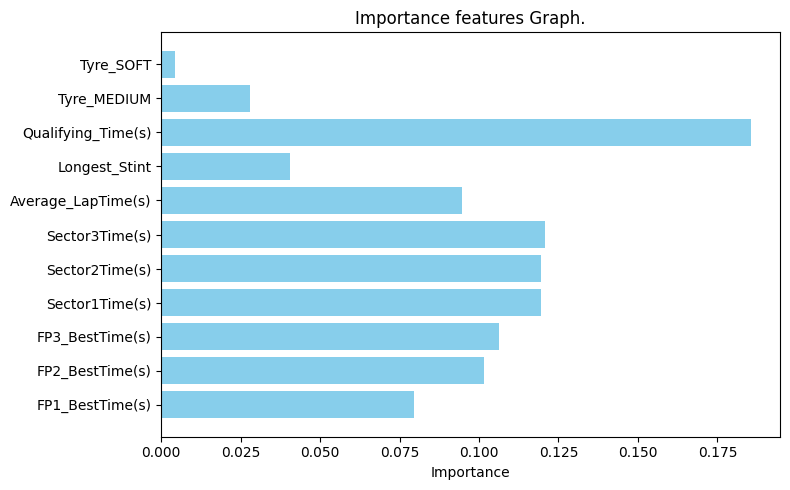

In [36]:
plt.figure(figsize=(8,5))
plt.barh(features, feature_importance, color='skyblue')
plt.xlabel("Importance")
plt.title("Importance features Graph.")
plt.tight_layout()
plt.show()

In [37]:
df1 = df1.sort_values(by=["Predicted_standing","Qualifying_Time(s)"]).reset_index(drop=True)

In [38]:
df1

,Driver,FP1_BestTime(s),FP2_BestTime(s),FP3_BestTime(s),Sector1Time(s),Sector2Time(s),Sector3Time(s),Average_LapTime(s),Longest_Stint,Qualifying_Time(s),Season,Round,Tyre_SOFT,Tyre_MEDIUM,Predicted_standing
0,ANT,92.861,92.861,92.861,32.343462,32.096967,48.194900,105.921522,11,92.064,2026,2,False,False,12.413333
1,RUS,92.741,92.741,92.741,30.327320,31.405759,48.234931,105.158174,11,92.286,2026,2,False,False,12.413333
2,LEC,93.599,93.599,93.599,32.860423,33.491536,50.693214,113.860333,12,92.428,2026,2,False,False,12.413333
3,GAS,94.676,94.676,94.676,33.422160,33.925786,49.431607,113.042043,11,92.873,2026,2,False,False,12.413333
4,HAD,94.856,94.856,94.856,31.163739,33.078654,50.332462,112.336909,12,93.121,2026,2,False,False,12.413333
5,COL,94.947,94.947,94.947,31.392652,33.855077,50.476192,110.578381,11,93.357,2026,2,False,False,12.413333
6,LAW,94.773,94.773,94.773,30.865720,32.645276,49.543448,108.429043,11,93.765,2026,2,False,False,12.413333
7,ALB,95.480,95.480,95.480,33.604207,32.648226,51.148677,109.265840,12,94.772,2026,2,False,False,12.413333
8,HAM,94.129,94.129,94.129,33.756348,36.281615,52.237846,115.147368,8,92.415,2026,2,True,False,12.533333
9,PIA,93.472,93.472,93.472,31.574320,32.584571,48.561143,110.552458,10,92.550,2026,2,False,False,12.533333


In [41]:
podium = df1.loc[:,["Driver"]]
print("\n Predicted Top 3")
print(f"🥇P1: {podium.iloc[0]['Driver']}")
print(f"🥈P2: {podium.iloc[1]['Driver']}")
print(f"🥉P3: {podium.iloc[2]['Driver']}")
print(f"P4: {podium.iloc[3]['Driver']}")
print(f"P5: {podium.iloc[4]['Driver']}")
print(f"P6: {podium.iloc[5]['Driver']}")
print(f"P7: {podium.iloc[6]['Driver']}")
print(f"P8: {podium.iloc[7]['Driver']}")
print(f"P9: {podium.iloc[8]['Driver']}")
print(f"P10: {podium.iloc[9]['Driver']}")
print(f"P11: {podium.iloc[10]['Driver']}")
print(f"P12: {podium.iloc[11]['Driver']}")

print(f"Spearman Rank: {corr:.2f}")


 Predicted Top 3
🥇P1: ANT
🥈P2: RUS
🥉P3: LEC
P4: GAS
P5: HAD
P6: COL
P7: LAW
P8: ALB
P9: HAM
P10: PIA
P11: NOR
P12: VER
Spearman Rank: 0.80
